# CNN - VNINDEX

## Descriptions
1. Features: ["close"]
1. Target: "close"
1. Timeshift: 40
1. Forecast horizon: 1

## Deploy TensorBoard

In [64]:
# tensorboard --logdir=src/model/lightning_logs/

## Import libraries

In [65]:
import os
import sys
import json
import ipynbname
import pandas as pd
import lightning as L
import torch.nn as nn
import torch
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tsfresh.utilities.dataframe_functions import (
    roll_time_series,
)
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import ComprehensiveFCParameters
import matplotlib.pylab as plt
from sklearn.preprocessing import MinMaxScaler
from lightning.pytorch.callbacks import EarlyStopping
from pprint import pprint

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from utils.constants import FEATURE_SELECTION_LOG_FILE_BASE
from tabular_database_driver.postgre_sql_driver import PostgreSQLDriver
from dtos.tabular_database_driver_dtos.postgre_sql_connection_dto import (
    PostgreSQLConnectionDto,
)

## Parameters

In [66]:
RANDOM_SEED = 18

In [67]:
MAX_TIMESHIFT = 40
MIN_TIMESHIFT = 40

In [68]:
FORECAST_HORIZON = 1

In [69]:
COLUMN_ID = "stock"
TARGET_COLUMN = "close"
DATE_COLUMN = "date"

In [70]:
# Inclusive
TRAIN_RANGE = ("2000-01-01", "2021-12-31")
VALIDATION_RANGE = ("2022-01-01", "2023-12-31")
TEST_RANGE = ("2024-01-01", "2026-02-26")

In [71]:
INPUT_SIZE = None
OUTPUT_SIZE = 1

## Hyper Parameters

In [72]:
MAX_EPOCHS = 1000
LEARNING_RATE = 0.00001
PATIENCE = 35
BATCH_SIZE = 128

## Start

### Get data

In [73]:
my_logger = Logger(file_name=f"{FEATURE_SELECTION_LOG_FILE_BASE}/vn_index/test")

In [74]:
my_connection_model = PostgreSQLConnectionDto(
    logger=my_logger,
    host=os.getenv("POSTGRES_HOST"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    port=os.getenv("POSTGRES_PORT"),
    database=os.getenv("GOLD_POSTGRES_DATABASE"),
)

In [75]:
my_postgresql_driver = PostgreSQLDriver(logger=my_logger)
my_postgresql_driver.connect(my_connection_model)

<DatabaseExecutionStatus.SUCCESS: 'success'>

In [76]:
vn_index_df = my_postgresql_driver.select(
    schema_name="stock_market", table_name="vn_index"
)

In [77]:
dtype_map = {
    "date": str,
    "open": float,
    "high": float,
    "low": float,
    "close": float,
    "matching_volume": float,
}

vn_index_df = (
    vn_index_df.astype(dtype_map)
    .dropna(subset=["close"])
    .sort_values(by=["date"])
    .reset_index(drop=True)
)

In [78]:
vn_index_df

,date,open,high,low,close,adjust,change,percent_change,matching_volume,matching_value,negotiate_volume,negotiate_value,number_of_buy_orders,buy_volume,average_volume_per_buy_order,number_of_sell_orders,sell_volume,average_volume_per_sell_order,net_volume
0,2008-03-07,640.140,640.140,640.140,640.140,640.14,28.97,4.74,8.169220e+06,515253831000.0,350040.0,29103040000.0,26816.0,5.268141e+07,1965.0,3448.0,9.057040e+06,2627.0,4.362437e+07
1,2008-03-08,646.190,646.190,646.190,646.190,646.1899999999999,25.363333333333333,4.1066666666666665,1.314382e+07,829832099333.3333,769057.0,45944657000.0,27442.0,5.068024e+07,1852.3333333333333,7486.0,1.712815e+07,2464.0,3.355209e+07
2,2008-03-09,652.240,652.240,652.240,652.240,652.24,21.756666666666664,3.4733333333333336,1.811842e+07,1144410367666.6665,1188073.0,62786274000.0,28068.0,4.867907e+07,1739.6666666666667,11523.0,2.519927e+07,2301.0,2.347980e+07
3,2008-03-10,658.290,658.290,658.290,658.290,658.29,18.15,2.84,2.309302e+07,1458988636000.0,1607090.0,79627891000.0,28694.0,4.667790e+07,1627.0,15561.0,3.327038e+07,2138.0,1.340752e+07
4,2008-03-11,638.710,638.710,638.710,638.710,638.71,-19.58,-2.97,1.384280e+07,837466500000.0,226000.0,12099600000.0,14464.0,1.933131e+07,1337.0,17910.0,2.811427e+07,1570.0,-8.782960e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6561,2026-02-22,1832.317,1859.236,1829.801,1856.535,1856.535,33.44499999999999,1.837,7.158068e+08,22272405365000.0,23581058.0,792440247700.0,476711.0,1.233848e+09,2591.3,393692.0,1.198445e+09,3047.9,3.540296e+07
6562,2026-02-23,1833.900,1863.130,1833.900,1860.140,1860.14,36.05,1.98,7.313611e+08,22646206050000.0,23192200.0,777430868000.0,486603.0,1.253004e+09,2575.0,401281.0,1.213944e+09,3025.0,3.906029e+07
6563,2026-02-24,1862.180,1867.690,1849.600,1867.620,1867.62,7.48,0.4,9.667547e+08,31205940310000.0,22413147.0,779573446300.0,598087.0,1.575227e+09,2634.0,507471.0,1.648273e+09,3248.0,-7.304628e+07
6564,2026-02-25,1869.490,1876.010,1855.890,1860.910,1860.91,-6.71,-0.36,1.083635e+09,35678521520000.0,62225450.0,1856894317550.0,694266.0,1.862364e+09,2682.0,597096.0,1.892734e+09,3170.0,-3.036983e+07


In [79]:
vn_index_df_close = vn_index_df[["date", "close"]]
vn_index_df_close

,date,close
0,2008-03-07,640.140
1,2008-03-08,646.190
2,2008-03-09,652.240
3,2008-03-10,658.290
4,2008-03-11,638.710
...,...,...
6561,2026-02-22,1856.535
6562,2026-02-23,1860.140
6563,2026-02-24,1867.620
6564,2026-02-25,1860.910


In [80]:
vn_index_df_close.loc[:, "stock"] = "vn_index"
vn_index_df_close

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2200\2662759176.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vn_index_df_close.loc[:, "stock"] = "vn_index"


,date,close,stock
0,2008-03-07,640.140,vn_index
1,2008-03-08,646.190,vn_index
2,2008-03-09,652.240,vn_index
3,2008-03-10,658.290,vn_index
4,2008-03-11,638.710,vn_index
...,...,...,...
6561,2026-02-22,1856.535,vn_index
6562,2026-02-23,1860.140,vn_index
6563,2026-02-24,1867.620,vn_index
6564,2026-02-25,1860.910,vn_index


In [81]:
input_df = vn_index_df_close

### Roll time series

In [82]:
input_df_rolled = roll_time_series(
    input_df,
    column_id=COLUMN_ID,
    column_sort=DATE_COLUMN,
    max_timeshift=MAX_TIMESHIFT,
    min_timeshift=MIN_TIMESHIFT,
)
input_df_rolled

Rolling: 100%|██████████| 50/50 [00:04<00:00, 10.26it/s]


,date,close,stock,id
0,2008-03-07,640.140,vn_index,"(vn_index, 2008-04-16)"
1,2008-03-08,646.190,vn_index,"(vn_index, 2008-04-16)"
2,2008-03-09,652.240,vn_index,"(vn_index, 2008-04-16)"
3,2008-03-10,658.290,vn_index,"(vn_index, 2008-04-16)"
4,2008-03-11,638.710,vn_index,"(vn_index, 2008-04-16)"
...,...,...,...,...
251325,2026-02-22,1856.535,vn_index,"(vn_index, 2026-02-26)"
251326,2026-02-23,1860.140,vn_index,"(vn_index, 2026-02-26)"
251327,2026-02-24,1867.620,vn_index,"(vn_index, 2026-02-26)"
251328,2026-02-25,1860.910,vn_index,"(vn_index, 2026-02-26)"


### Extract features

In [83]:
X = extract_features(
    input_df_rolled.drop(COLUMN_ID, axis=1),
    column_id="id",
    column_sort=DATE_COLUMN,
    impute_function=impute,
    default_fc_parameters=ComprehensiveFCParameters(),
)

Feature Extraction: 100%|██████████| 50/50 [00:53<00:00,  1.06s/it]


In [84]:
X

close__variance_larger_than_standard_deviation  \
vn_index 2008-04-16                                             1.0   
         2008-04-17                                             1.0   
         2008-04-18                                             1.0   
         2008-04-19                                             1.0   
         2008-04-20                                             1.0   
...                                                             ...   
         2026-02-22                                             1.0   
         2026-02-23                                             1.0   
         2026-02-24                                             1.0   
         2026-02-25                                             1.0   
         2026-02-26                                             1.0   

                     close__has_duplicate_max  close__has_duplicate_min  \
vn_index 2008-04-16                       0.0                       0.0   
         2008-04-17                       0.0                       0.0   
         2008-04-18                       0.0                       0.0   
         2008-04-19                       0.0                       0.0   
         2008-04-20                       0.0                       0.0   
...                                       ...                       ...   
         2026-02-22                       0.0                       0.0   
         2026-02-23                       0.0                       0.0   
         2026-02-24                       0.0                       0.0   
         2026-02-25                       0.0                       0.0   
         2026-02-26                       0.0                       0.0   

                     close__has_duplicate  close__sum_values  \
vn_index 2008-04-16                   0.0       23058.780000   
         2008-04-17                   0.0       22956.220000   
         2008-04-18                   0.0       22847.340000   
         2008-04-19                   0.0       22731.613333   
         2008-04-20                   0.0       22609.040000   
...                                   ...                ...   
         2026-02-22                   0.0       75200.155000   
         2026-02-23                   0.0       75157.365000   
         2026-02-24                   0.0       75130.545000   
         2026-02-25                   0.0       75126.655000   
         2026-02-26                   0.0       75127.165000   

                     close__abs_energy  close__mean_abs_change  \
vn_index 2008-04-16       1.307299e+07                6.841500   
         2008-04-17       1.295220e+07                6.845250   
         2008-04-18       1.282334e+07                6.700750   
         2008-04-19       1.268577e+07                6.569417   
         2008-04-20       1.253942e+07                6.099833   
...                                ...                     ...   
         2026-02-22       1.380027e+08                9.526125   
         2026-02-23       1.378417e+08                9.404000   
         2026-02-24       1.377408e+08                8.850000   
         2026-02-25       1.377263e+08                8.659500   
         2026-02-26       1.377282e+08                8.982250   

                     close__mean_change  \
vn_index 2008-04-16           -2.719000   
         2008-04-17           -2.715250   
         2008-04-18           -2.873250   
         2008-04-19           -3.044417   
         2008-04-20           -2.574833   
...                                 ...   
         2026-02-22           -1.159875   
         2026-02-23           -0.857500   
         2026-02-24            0.070500   
         2026-02-25           -0.455500   
         2026-02-26           -0.132750   

                     close__mean_second_derivative_central  close__median  \
vn_index 2008-04-16                              -0.097128     539.010000   
         2008-04-17               

In [85]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-04-16,1.0,0.0,0.0,0.0,23058.780000,1.307299e+07,6.841500,-2.719000,-0.097128,539.010000,...,0.501047,0.501047,0.750969,1.073526,1.486890,1.828869,2.041122,2.253249,0.0,647.451429
2008-04-17,1.0,0.0,0.0,0.0,22956.220000,1.295220e+07,6.845250,-2.715250,0.001923,537.580000,...,0.567061,0.567061,0.750969,1.171044,1.581692,1.828869,2.041122,2.253249,0.0,647.247143
2008-04-18,1.0,0.0,0.0,0.0,22847.340000,1.282334e+07,6.700750,-2.873250,-0.081026,537.484000,...,0.567061,0.567061,0.750969,1.266959,1.581692,1.828869,2.041122,2.253249,0.0,645.568095
2008-04-19,1.0,0.0,0.0,0.0,22731.613333,1.268577e+07,6.569417,-3.044417,0.240812,537.476667,...,0.567061,0.567061,0.750969,1.216894,1.581692,1.828869,2.041122,2.253249,0.0,641.687143
2008-04-20,1.0,0.0,0.0,0.0,22609.040000,1.253942e+07,6.099833,-2.574833,-0.076752,537.310000,...,0.567061,0.567061,0.932074,1.151988,1.519735,1.828869,2.041122,2.253249,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-22,1.0,0.0,0.0,0.0,75200.155000,1.380027e+08,9.526125,-1.159875,0.155064,1834.905000,...,0.501047,0.684955,1.219137,1.266959,1.779219,2.216408,2.659323,2.859007,0.0,1892.700000
2026-02-23,1.0,0.0,0.0,0.0,75157.365000,1.378417e+08,9.404000,-0.857500,0.426218,1834.905000,...,0.501047,0.684955,1.219137,1.268562,1.736695,2.163308,2.572115,2.772888,0.0,1889.814286
2026-02-24,1.0,0.0,0.0,0.0,75130.545000,1.377408e+08,8.850000,0.070500,-0.087821,1834.905000,...,0.501047,0.684955,1.299752,1.220007,1.678375,2.070280,2.481814,2.683189,0.0,1887.627143


### Create forecast target

In [86]:
y = (
    vn_index_df_close.set_index(DATE_COLUMN)
    .sort_index()[TARGET_COLUMN]
    .shift(-FORECAST_HORIZON)
    .dropna()
)
y = pd.DataFrame(y)
y

,close
date,
2008-03-07,646.190
2008-03-08,652.240
2008-03-09,658.290
2008-03-10,638.710
2008-03-11,643.900
...,...
2026-02-21,1856.535
2026-02-22,1860.140
2026-02-23,1867.620


In [87]:
y = y[y.index.isin(X.index)]
X = X[X.index.isin(y.index)]

In [88]:
X

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-04-16,1.0,0.0,0.0,0.0,23058.780000,1.307299e+07,6.841500,-2.719000,-0.097128,539.010000,...,0.501047,0.501047,0.750969,1.073526,1.486890,1.828869,2.041122,2.253249,0.0,647.451429
2008-04-17,1.0,0.0,0.0,0.0,22956.220000,1.295220e+07,6.845250,-2.715250,0.001923,537.580000,...,0.567061,0.567061,0.750969,1.171044,1.581692,1.828869,2.041122,2.253249,0.0,647.247143
2008-04-18,1.0,0.0,0.0,0.0,22847.340000,1.282334e+07,6.700750,-2.873250,-0.081026,537.484000,...,0.567061,0.567061,0.750969,1.266959,1.581692,1.828869,2.041122,2.253249,0.0,645.568095
2008-04-19,1.0,0.0,0.0,0.0,22731.613333,1.268577e+07,6.569417,-3.044417,0.240812,537.476667,...,0.567061,0.567061,0.750969,1.216894,1.581692,1.828869,2.041122,2.253249,0.0,641.687143
2008-04-20,1.0,0.0,0.0,0.0,22609.040000,1.253942e+07,6.099833,-2.574833,-0.076752,537.310000,...,0.567061,0.567061,0.932074,1.151988,1.519735,1.828869,2.041122,2.253249,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,1.0,0.0,0.0,0.0,75220.950000,1.380804e+08,10.076000,-0.610000,-0.281987,1834.905000,...,0.501047,0.684955,1.110201,1.312200,1.819548,2.304268,2.743049,2.941031,0.0,1892.700000
2026-02-22,1.0,0.0,0.0,0.0,75200.155000,1.380027e+08,9.526125,-1.159875,0.155064,1834.905000,...,0.501047,0.684955,1.219137,1.266959,1.779219,2.216408,2.659323,2.859007,0.0,1892.700000
2026-02-23,1.0,0.0,0.0,0.0,75157.365000,1.378417e+08,9.404000,-0.857500,0.426218,1834.905000,...,0.501047,0.684955,1.219137,1.268562,1.736695,2.163308,2.572115,2.772888,0.0,1889.814286


In [89]:
y

,close
date,
2008-04-16,537.580000
2008-04-17,537.310000
2008-04-18,536.513333
2008-04-19,535.716667
2008-04-20,534.920000
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create train set

In [90]:
TRAIN_RANGE[0], TRAIN_RANGE[1]

('2000-01-01', '2021-12-31')

In [91]:
X_train = X.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
X_train

,close__variance_larger_than_standard_deviation,close__has_duplicate_max,close__has_duplicate_min,close__has_duplicate,close__sum_values,close__abs_energy,close__mean_abs_change,close__mean_change,close__mean_second_derivative_central,close__median,...,close__fourier_entropy__bins_5,close__fourier_entropy__bins_10,close__fourier_entropy__bins_100,close__permutation_entropy__dimension_3__tau_1,close__permutation_entropy__dimension_4__tau_1,close__permutation_entropy__dimension_5__tau_1,close__permutation_entropy__dimension_6__tau_1,close__permutation_entropy__dimension_7__tau_1,close__query_similarity_count__query_None__threshold_0.0,close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2008-04-16,1.0,0.0,0.0,0.0,23058.780000,1.307299e+07,6.841500,-2.719000,-0.097128,539.010000,...,0.501047,0.501047,0.750969,1.073526,1.486890,1.828869,2.041122,2.253249,0.0,647.451429
2008-04-17,1.0,0.0,0.0,0.0,22956.220000,1.295220e+07,6.845250,-2.715250,0.001923,537.580000,...,0.567061,0.567061,0.750969,1.171044,1.581692,1.828869,2.041122,2.253249,0.0,647.247143
2008-04-18,1.0,0.0,0.0,0.0,22847.340000,1.282334e+07,6.700750,-2.873250,-0.081026,537.484000,...,0.567061,0.567061,0.750969,1.266959,1.581692,1.828869,2.041122,2.253249,0.0,645.568095
2008-04-19,1.0,0.0,0.0,0.0,22731.613333,1.268577e+07,6.569417,-3.044417,0.240812,537.476667,...,0.567061,0.567061,0.750969,1.216894,1.581692,1.828869,2.041122,2.253249,0.0,641.687143
2008-04-20,1.0,0.0,0.0,0.0,22609.040000,1.253942e+07,6.099833,-2.574833,-0.076752,537.310000,...,0.567061,0.567061,0.932074,1.151988,1.519735,1.828869,2.041122,2.253249,0.0,635.604286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,1.0,0.0,0.0,0.0,60248.090000,8.854721e+07,7.924250,0.325750,0.127821,1476.210000,...,0.750969,1.044187,1.883954,1.418143,2.267825,2.828328,3.222411,3.396914,0.0,1490.664286
2021-12-28,1.0,0.0,0.0,0.0,60266.630000,8.860228e+07,7.911500,0.614000,0.294744,1476.610000,...,0.684955,0.978173,1.803141,1.428135,2.282232,2.863924,3.275454,3.436523,0.0,1491.978571
2021-12-29,1.0,0.0,0.0,0.0,60282.620000,8.864954e+07,7.688750,0.836750,-0.088077,1477.030000,...,0.684955,0.978173,1.838799,1.522339,2.364851,2.931546,3.313962,3.436523,0.0,1491.978571


In [92]:
y_train = y.loc[TRAIN_RANGE[0] : TRAIN_RANGE[1]]
y_train

,close
date,
2008-04-16,537.580000
2008-04-17,537.310000
2008-04-18,536.513333
2008-04-19,535.716667
2008-04-20,534.920000
...,...
2021-12-27,1494.390000
2021-12-28,1485.820000
2021-12-29,1485.970000


### Select features

In [93]:
X_train_selected = select_features(X_train, y_train[TARGET_COLUMN])
X_train_selected

,close__sum_values,close__c3__lag_1,close__c3__lag_2,close__c3__lag_3,close__quantile__q_0.2,close__quantile__q_0.1,close__quantile__q_0.4,close__quantile__q_0.3,close__quantile__q_0.8,close__quantile__q_0.7,...,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__friedrich_coefficients__coeff_0__m_3__r_30,close__has_duplicate_max,close__count_above_mean,close__count_below_mean,close__lempel_ziv_complexity__bins_10,close__autocorrelation__lag_5,close__ratio_beyond_r_sigma__r_3,close__fourier_entropy__bins_10
last_date,,,,,,,,,,,,,,,,,,,,,
2008-04-16,23058.780000,1.808704e+08,1.787654e+08,1.764916e+08,521.07,514.083333,535.958000,531.380000,634.436667,573.45,...,0.974137,0.974137,0.000031,0.0,14.0,27.0,0.536585,0.675519,0.00000,0.501047
2008-04-17,22956.220000,1.778557e+08,1.757076e+08,1.731191e+08,521.07,514.083333,535.958000,531.380000,625.073333,564.82,...,0.966338,0.966338,0.000023,0.0,13.0,28.0,0.536585,0.636893,0.00000,0.567061
2008-04-18,22847.340000,1.746772e+08,1.724289e+08,1.699244e+08,521.07,514.083333,535.958000,531.380000,615.710000,552.05,...,0.953654,0.953654,0.000025,0.0,12.0,29.0,0.536585,0.585335,0.00000,0.567061
2008-04-19,22731.613333,1.716191e+08,1.692915e+08,1.666772e+08,521.07,514.083333,535.958000,531.380000,588.260000,548.56,...,0.935723,0.935723,0.000031,0.0,11.0,30.0,0.536585,0.523677,0.00000,0.567061
2008-04-20,22609.040000,1.686370e+08,1.660500e+08,1.634611e+08,521.07,514.083333,535.716667,531.380000,573.450000,545.73,...,0.948166,0.948166,0.000056,0.0,11.0,30.0,0.512195,0.454373,0.00000,0.567061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,60248.090000,3.170478e+09,3.169770e+09,3.172345e+09,1452.35,1446.770000,1471.986667,1463.630000,1484.840000,1478.97,...,0.811695,0.811695,-0.000047,0.0,26.0,15.0,0.560976,-0.169950,0.00000,1.044187
2021-12-28,60266.630000,3.174411e+09,3.174415e+09,3.176253e+09,1452.35,1446.770000,1471.986667,1463.630000,1484.930000,1479.79,...,0.813799,0.813799,-0.000075,0.0,25.0,16.0,0.560976,-0.176925,0.00000,0.978173
2021-12-29,60282.620000,3.179775e+09,3.179561e+09,3.177501e+09,1452.35,1446.770000,1475.500000,1463.630000,1485.190000,1480.98,...,0.825988,0.825988,-0.000124,0.0,26.0,15.0,0.560976,-0.166418,0.00000,0.978173


In [94]:
INPUT_SIZE = X_train_selected.shape[1]
INPUT_SIZE

339

### Create validation set

In [95]:
VALIDATION_RANGE[0], VALIDATION_RANGE[1]

('2022-01-01', '2023-12-31')

In [96]:
X_validation_selected = X.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]][
    X_train_selected.columns
]
X_validation_selected

,close__sum_values,close__c3__lag_1,close__c3__lag_2,close__c3__lag_3,close__quantile__q_0.2,close__quantile__q_0.1,close__quantile__q_0.4,close__quantile__q_0.3,close__quantile__q_0.8,close__quantile__q_0.7,...,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__friedrich_coefficients__coeff_0__m_3__r_30,close__has_duplicate_max,close__count_above_mean,close__count_below_mean,close__lempel_ziv_complexity__bins_10,close__autocorrelation__lag_5,close__ratio_beyond_r_sigma__r_3,close__fourier_entropy__bins_10
last_date,,,,,,,,,,,,,,,,,,,,,
2022-01-01,60420.025000,3.200146e+09,3.194847e+09,3.187928e+09,1463.540000,1446.770000,1476.610000,1471.986667,1487.570000,1484.93,...,0.791887,0.791887,0.000027,0.0,28.0,13.0,0.536585,0.027515,0.02439,0.978173
2022-01-02,60484.705000,3.206703e+09,3.198865e+09,3.191184e+09,1463.630000,1446.770000,1477.030000,1475.500000,1488.870000,1485.19,...,0.814120,0.814120,-0.000024,0.0,29.0,12.0,0.536585,0.122171,0.02439,1.044187
2022-01-03,60539.830000,3.211462e+09,3.202193e+09,3.195635e+09,1467.763333,1446.770000,1477.330000,1476.020000,1488.880000,1485.82,...,0.837259,0.837259,0.000037,0.0,27.0,14.0,0.536585,0.161983,0.00000,1.044187
2022-01-04,60576.540000,3.215743e+09,3.206223e+09,3.199384e+09,1467.763333,1446.770000,1477.330000,1476.020000,1490.300000,1485.82,...,0.836749,0.836749,0.000065,0.0,24.0,17.0,0.536585,0.174656,0.00000,0.978173
2022-01-05,60598.230000,3.220568e+09,3.210525e+09,3.202378e+09,1467.763333,1446.770000,1477.330000,1476.020000,1490.300000,1485.82,...,0.865490,0.865490,0.000025,0.0,23.0,18.0,0.512195,0.215943,0.00000,0.775129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,45416.730000,1.358847e+09,1.358222e+09,1.357715e+09,1095.610000,1093.093333,1102.430000,1101.190000,1121.490000,1114.38,...,0.847245,0.847245,-0.000805,0.0,20.0,21.0,0.536585,0.143396,0.00000,0.567061
2023-12-28,45444.470000,1.360979e+09,1.359878e+09,1.359684e+09,1095.610000,1093.093333,1102.800000,1102.013333,1121.990000,1115.97,...,0.836383,0.836383,-0.001436,0.0,19.0,22.0,0.560976,0.146056,0.00000,0.567061
2023-12-29,45472.386667,1.363285e+09,1.361560e+09,1.361517e+09,1095.610000,1093.093333,1102.836667,1102.160000,1122.250000,1117.66,...,0.847197,0.847197,-0.000756,0.0,20.0,21.0,0.536585,0.134180,0.00000,0.567061


In [97]:
y_validation = y.loc[VALIDATION_RANGE[0] : VALIDATION_RANGE[1]]
y_validation

,close
date,
2022-01-01,1511.9300
2022-01-02,1518.7550
2022-01-03,1525.5800
2022-01-04,1522.5000
2022-01-05,1528.5700
...,...
2023-12-27,1128.9300
2023-12-28,1129.9300
2023-12-29,1130.3775


### Create test set

In [98]:
TEST_RANGE[0], TEST_RANGE[1]

('2024-01-01', '2026-02-26')

In [99]:
X_test_selected = X.loc[TEST_RANGE[0] : TEST_RANGE[1]][X_train_selected.columns]
X_test_selected

,close__sum_values,close__c3__lag_1,close__c3__lag_2,close__c3__lag_3,close__quantile__q_0.2,close__quantile__q_0.1,close__quantile__q_0.4,close__quantile__q_0.3,close__quantile__q_0.8,close__quantile__q_0.7,...,close__partial_autocorrelation__lag_1,close__autocorrelation__lag_1,close__friedrich_coefficients__coeff_0__m_3__r_30,close__has_duplicate_max,close__count_above_mean,close__count_below_mean,close__lempel_ziv_complexity__bins_10,close__autocorrelation__lag_5,close__ratio_beyond_r_sigma__r_3,close__fourier_entropy__bins_10
last_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,45547.905000,1.370191e+09,1.369893e+09,1.369976e+09,1095.610000,1093.093333,1103.060000,1102.16,1125.146667,1121.990000,...,0.882390,0.882390,-0.000665,0.0,21.0,20.0,0.585366,0.191766,0.0,0.501047
2024-01-02,45565.805000,1.373255e+09,1.373007e+09,1.372880e+09,1095.610000,1093.093333,1103.060000,1102.16,1125.500000,1122.250000,...,0.897689,0.897689,-0.000811,0.0,21.0,20.0,0.585366,0.242615,0.0,0.501047
2024-01-03,45621.485000,1.377390e+09,1.377561e+09,1.377210e+09,1096.300000,1094.130000,1107.926667,1102.30,1126.430000,1124.440000,...,0.877998,0.877998,0.000072,0.0,22.0,19.0,0.560976,0.253498,0.0,0.501047
2024-01-04,45676.595000,1.382107e+09,1.381988e+09,1.381971e+09,1098.826667,1094.130000,1108.270000,1102.43,1127.630000,1124.793333,...,0.865847,0.865847,0.000574,0.0,22.0,19.0,0.585366,0.279509,0.0,0.567061
2024-01-05,45738.181667,1.387830e+09,1.386933e+09,1.386468e+09,1100.760000,1095.353333,1110.130000,1102.80,1128.930000,1125.146667,...,0.864266,0.864266,-0.000020,0.0,21.0,20.0,0.560976,0.274148,0.0,0.567061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-21,75220.950000,6.167192e+09,6.147817e+09,6.128149e+09,1802.910000,1755.490000,1827.695000,1814.09,1879.130000,1861.766667,...,0.959573,0.959573,-0.000041,0.0,21.0,20.0,0.585366,0.613985,0.0,0.684955
2026-02-22,75200.155000,6.156781e+09,6.138127e+09,6.118671e+09,1802.910000,1755.490000,1827.695000,1814.09,1879.130000,1856.535000,...,0.941603,0.941603,-0.000040,0.0,21.0,20.0,0.585366,0.590860,0.0,0.684955
2026-02-23,75157.365000,6.148483e+09,6.129283e+09,6.105601e+09,1802.910000,1755.490000,1827.695000,1814.09,1870.790000,1856.535000,...,0.942559,0.942559,-0.000031,0.0,21.0,20.0,0.560976,0.559050,0.0,0.684955


In [100]:
y_test = y.loc[TEST_RANGE[0] : TEST_RANGE[1]]
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


### Create scaler

In [101]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaler = X_scaler.fit_transform(X_train_selected)
y_train_scaler = y_scaler.fit_transform(y_train)

X_validation_scaler = X_scaler.transform(X_validation_selected)
y_validation_scaler = y_scaler.transform(y_validation)

X_test_scaler = X_scaler.transform(X_test_selected)
y_test_scaler = y_scaler.transform(y_test)

In [102]:
X_train_scaler.shape

(5008, 339)

In [103]:
y_train_scaler.shape

(5008, 1)

In [104]:
X_validation_scaler.shape

(730, 339)

In [105]:
y_validation_scaler.shape

(730, 1)

In [106]:
X_test_scaler.shape

(787, 339)

In [107]:
y_test_scaler.shape

(787, 1)

### Create dataloader

In [108]:
train_dataset = TensorDataset(
    torch.tensor(X_train_scaler, dtype=torch.float32),
    torch.tensor(y_train_scaler, dtype=torch.float32),
)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [109]:
validation_dataset = TensorDataset(
    torch.tensor(X_validation_scaler, dtype=torch.float32),
    torch.tensor(y_validation_scaler, dtype=torch.float32),
)
validation_dataloader = DataLoader(validation_dataset, batch_size=BATCH_SIZE)

In [110]:
test_dataset = TensorDataset(
    torch.tensor(X_test_scaler, dtype=torch.float32),
    torch.tensor(y_test_scaler, dtype=torch.float32),
)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

### Create model

In [111]:
class LightningCNN(L.LightningModule):

    def __init__(self, random_seed, input_size):
        super().__init__()

        L.seed_everything(seed=random_seed)

        self.input_size = int(input_size)

        if self.input_size <= 0:
            raise Exception("input_size must be greater than 0")

        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * (self.input_size // 4), 64), nn.ReLU(), nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.unsqueeze(1)

        x = self.conv(x)
        x = x.view(x.size(0), -1)

        x = self.fc(x)
        return x

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=LEARNING_RATE)

    def training_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("train_loss", loss)
        return loss

    def validation_step(self, batch):
        input_i, label_i = batch
        output_i = self(input_i)

        loss = F.mse_loss(output_i, label_i)
        self.log("val_loss", loss, prog_bar=True)
        return loss

In [112]:
model = LightningCNN(RANDOM_SEED, INPUT_SIZE)

Seed set to 18


### Train model

In [113]:
early_stop_callback = EarlyStopping(
    monitor="val_loss",  # metric to watch
    patience=PATIENCE,  # epochs to wait before stopping
    mode="min",  # because lower loss is better
)

In [114]:
trainer = L.Trainer(
    max_epochs=MAX_EPOCHS, log_every_n_steps=1, callbacks=[early_stop_callback]
)

trainer.fit(
    model, train_dataloaders=train_dataloader, val_dataloaders=validation_dataloader
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │  6.3 K │ train │     0 │
│ 1 │ fc   │ Sequential │  344 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 350 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 350 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

d:\GIT\master-thesis\mt_env\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 
'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

In [115]:
y_test

,close
date,
2024-01-01,1131.720000
2024-01-02,1144.170000
2024-01-03,1150.720000
2024-01-04,1154.680000
2024-01-05,1156.516667
...,...
2026-02-21,1856.535000
2026-02-22,1860.140000
2026-02-23,1867.620000


In [116]:
y_test.shape

(787, 1)

In [117]:
y_pred_tensor = model(torch.tensor(X_test_scaler, dtype=torch.float32))

y_pred_numpy = y_pred_tensor.detach().cpu().numpy()

# Ensure correct shape for the scaler
y_pred_numpy = y_pred_numpy.reshape(-1, 1)

# Inverse transform
y_pred_inverse = y_scaler.inverse_transform(y_pred_numpy)

# Create Pandas Dataframe
y_predict_plot = pd.DataFrame(
    y_pred_inverse.squeeze(), index=X_test_selected.index, columns=["predict"]
)

y_predict_plot

,predict
last_date,
2024-01-01,1129.444336
2024-01-02,1130.888184
2024-01-03,1141.953003
2024-01-04,1149.670410
2024-01-05,1146.942383
...,...
2026-02-21,1801.226929
2026-02-22,1805.787598
2026-02-23,1811.206787


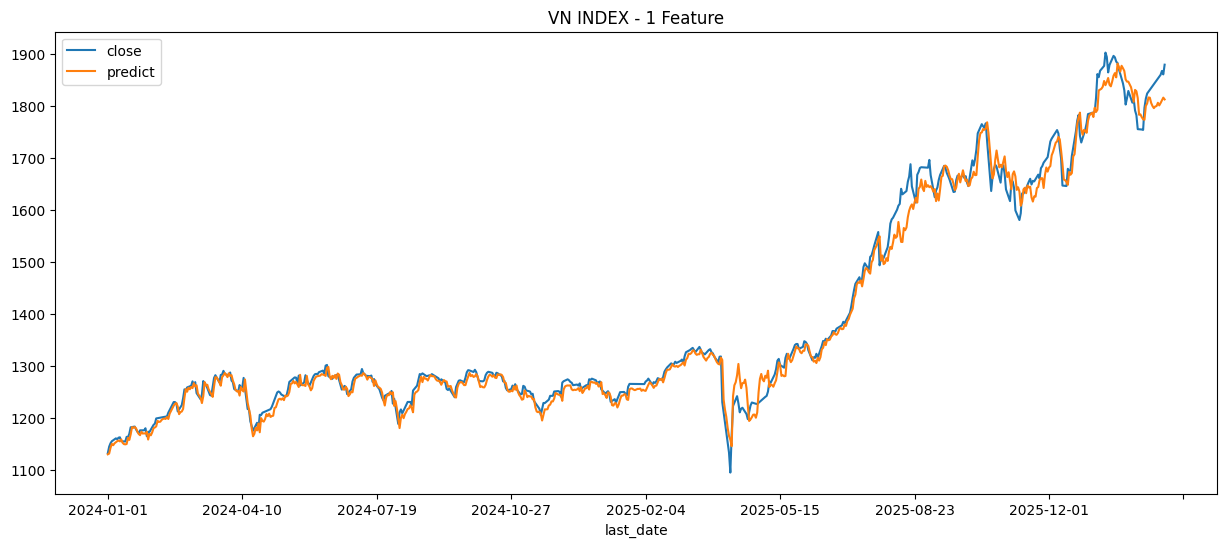

In [118]:
plt.figure(figsize=(15, 6))
plt.title("VN INDEX - 1 Feature")

y_test.plot(ax=plt.gca(), legend="close")
y_predict_plot.plot(ax=plt.gca(), legend="predict", marker=None)

plt.show()

In [119]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# Convert to numpy arrays (flatten in case they are DataFrames)
y_true = y_test.values.flatten()
y_pred = y_predict_plot.values.flatten()

In [120]:
# 1️⃣ MSE (Mean Squared Error)
mse = mean_squared_error(y_true, y_pred)

# 2️⃣ MAPE (Mean Absolute Percentage Error)
# Avoid division by zero
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# 3️⃣ RMSSE (Root Mean Squared Scaled Error)
# RMSSE needs scaling by naive forecast (lag-1)
# denominator = mean squared difference of actuals
denominator = np.mean(np.diff(y_true) ** 2)
rmsse = np.sqrt(mse / denominator)

print(f"MSE: {mse:.4f}")
print(f"MAPE: {mape:.4f} %")
print(f"RMSSE: {rmsse:.4f}")

MSE: 452.6162
MAPE: 1.0245 %
RMSSE: 1.8602


### Predict

In [121]:
# Get last row and keep 2D shape
last_row = X_test_scaler[-1:]
last_row.shape

(1, 339)

In [122]:
# Convert to tensor
last_row_tensor = torch.tensor(last_row, dtype=torch.float32)

with torch.no_grad():
    y_pred = model(last_row_tensor)

y_pred_inverse = y_scaler.inverse_transform(y_pred.cpu().numpy().reshape(-1, 1))

y_predict = pd.DataFrame(
    y_pred_inverse, index=[X_test_selected.index[-1]], columns=["predict"]
)

y_predict.squeeze()

np.float32(1812.7737)

### Create output JSON

In [123]:
# output_dict = {
#     "nb_name": NB_NAME,
#     "max_timeshift": MAX_TIMESHIFT,
#     "min_timeshift": MIN_TIMESHIFT,
#     "forecast_horizon": FORECAST_HORIZON,
#     "original_features": input_df.columns,
#     "selected_feature_count": len(X_train_selected.columns),
#     "target": TARGET_COLUMN,
#     "train_range": TRAIN_RANGE,
#     "validation_range": VALIDATION_RANGE,
#     "test_range": TEST_RANGE,
#     "max_epochs": MAX_EPOCHS,
#     "learning_rate": LEARNING_RATE,
#     "batch_size": BATCH_SIZE,
#     "patience": PATIENCE,
#     "mse": mse,
#     "mape": mape,
#     "rmsse": rmsse,
#     "predict": float(y_predict.squeeze()),
# }


# sorted_output_dict = dict(sorted(output_dict.items()))
# pprint(sorted_output_dict)

In [124]:
# base_filename = f"{NB_NAME}_model_evaluation_results"
# extension = ".json"

# counter = 1
# filename = f"{base_filename}_{counter}{extension}"

# # Keep increasing until we find a free filename
# while os.path.exists(filename):
#     counter += 1
#     filename = f"{base_filename}_{counter}{extension}"

# with open(filename, "w") as f:
#     json.dump(sorted_output_dict, f, indent=4, default=str)

# print(f"Saved to: {filename}")

### Save data

In [126]:
import os
import sys
import ipynbname
import pickle

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from dtos.result_dtos.result_dto import ResultDto
from utils.constants import RESULT_BASE_DIR
from utils.enums import (
    LossFunctionType,
    ModelAchitectureType,
    OptimizerType,
    ScalerType,
)
from utils.utils import create_next_directory, save_prediction_figure, save_result_dto


# Notebook name
NB_NAME = ipynbname.name()

# Create result directory
result_folder = create_next_directory(
    base_path=RESULT_BASE_DIR, prefix=f"{NB_NAME}_run"
)

# -----------------------
# Save experiment metadata
# -----------------------
result_dto = ResultDto(
    # Data
    base_features=["close"],
    stock_code="vn_index",
    train_start_date=TRAIN_RANGE[0],
    train_end_date=TRAIN_RANGE[1],
    validation_start_date=VALIDATION_RANGE[0],
    validation_end_date=VALIDATION_RANGE[1],
    test_start_date=TEST_RANGE[0],
    test_end_date=TEST_RANGE[1],
    # Data Hyperparameters
    random_seed=RANDOM_SEED,
    lookback_window_size=MAX_TIMESHIFT,
    forecast_window_size=FORECAST_HORIZON,
    scaler_type=ScalerType.MINMAX,
    # Model
    model_architecture=ModelAchitectureType.CNN,
    model_params={},
    # Training Hyperparameters
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    patience=PATIENCE,
    # Metrics
    mse=mse,
    mape=mape,
    rmsse=rmsse,
)

save_result_dto(save_path=result_folder, result_dto=result_dto)

# -----------------------
# Save model
# -----------------------
pickle_path = os.path.join(result_folder, "model.pkl")
with open(pickle_path, "wb") as f:
    pickle.dump(model, f)

# -----------------------
# Save prediction figure
# -----------------------
fig_path = os.path.join(result_folder, f"{NB_NAME}.jpg")

save_prediction_figure(
    y_test=y_test, y_predict=y_predict_plot, save_path=fig_path, title=f"{NB_NAME}"
)

print(f"Saved results to: {result_folder}")

Saved results to: ../../results\cnn_vn_index_1_run_2
